# Logistics Data Analysis

## Objective

Analyze package logistics data to identify patterns related to:
- Delivery performance
- Shipping costs
- Providers
- Shipping methods
- Destination provinces
- Delivery delays

The analysis includes an initial data quality review, data cleaning, and exploratory analysis using the cleaned dataset.

In [94]:
from IPython.core.interactiveshell import InteractiveShell
import pandas as pd
import matplotlib.pyplot as plt

InteractiveShell.ast_node_interactivity = "all"

## 1. Initial Dataset Exploration

The original synthetic dataset contains package orders from Amazon, Temu, and AliExpress.

Before analyzing the data, an initial exploration is performed to understand its structure and contents.

In [95]:
df = pd.read_csv("../data/raw/packages.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 14)


,package_id,provider,origin_country,destination_province,order_date,ship_date,estimated_delivery_date,actual_delivery_date,weight_kg,shipping_cost_usd,shipping_method,status,delivery_attempts,damaged
0,PKG-00001,AliExpress,USA,San José,2026-06-28,2026-07-01,2026-07-07,2026-07-10,13.25,23.08,Economy,Delivered,1,False
1,PKG-00002,Temu,China,Alajuela,2026-02-19,2026-02-24,2026-03-04,2026-03-09,7.70,13.58,Economy,Delivered,1,False
2,PKG-00003,AliExpress,China,Guanacaste,2026-07-11,2026-07-13,2026-07-22,2026-07-23,14.67,25.12,Economy,Delivered,1,False
3,PKG-00004,AliExpress,China,Alajuela,2026-04-11,2026-04-16,2026-04-24,2026-04-27,9.46,22.03,Standard,Delivered,1,False
4,PKG-00005,Temu,China,Guanacaste,2026-02-13,2026-02-18,2026-02-26,2026-03-03,3.99,16.45,Express,Delivered,1,False


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   package_id               10000 non-null  str    
 1   provider                 10000 non-null  str    
 2   origin_country           10000 non-null  str    
 3   destination_province     10000 non-null  str    
 4   order_date               10000 non-null  str    
 5   ship_date                10000 non-null  str    
 6   estimated_delivery_date  10000 non-null  str    
 7   actual_delivery_date     8612 non-null   str    
 8   weight_kg                10000 non-null  float64
 9   shipping_cost_usd        10000 non-null  float64
 10  shipping_method          10000 non-null  str    
 11  status                   10000 non-null  str    
 12  delivery_attempts        10000 non-null  int64  
 13  damaged                  10000 non-null  bool   
dtypes: bool(1), float64(2), int64(1), 

In [97]:
df.describe()

,weight_kg,shipping_cost_usd,delivery_attempts
count,10000.000000,10000.000000,10000.000000
mean,9.238159,23.062613,1.183500
std,3.272314,9.838742,0.459836
min,0.100000,3.730000,1.000000
25%,7.010000,15.867500,1.000000
50%,9.280000,21.440000,1.000000
75%,11.482500,28.470000,1.000000
max,21.760000,72.880000,3.000000


In [98]:
print("=== Providers ===")
print(df["provider"].value_counts())

print("\n=== Status ===")
print(df["status"].value_counts())

print("\n=== Shipping methods ===")
print(df["shipping_method"].value_counts())

=== Providers ===
provider
Amazon        3640
Temu          3415
AliExpress    2945
Name: count, dtype: int64

=== Status ===
status
Delivered     8054
In Transit     776
Delayed        558
Returned       417
Cancelled      195
Name: count, dtype: int64

=== Shipping methods ===
shipping_method
Economy     3982
Standard    3463
Express     2555
Name: count, dtype: int64


In [99]:
df.isna().sum()

package_id                    0
provider                      0
origin_country                0
destination_province          0
order_date                    0
ship_date                     0
estimated_delivery_date       0
actual_delivery_date       1388
weight_kg                     0
shipping_cost_usd             0
shipping_method               0
status                        0
delivery_attempts             0
damaged                       0
dtype: int64

In [100]:
df[df["actual_delivery_date"].notna() & 
   (df["actual_delivery_date"] < df["ship_date"])]

df[df["actual_delivery_date"].notna() & 
   (df["actual_delivery_date"] < df["ship_date"])]

df[(df["status"] == "In Transit") & 
   (df["actual_delivery_date"].notna())]

,package_id,provider,origin_country,destination_province,order_date,ship_date,estimated_delivery_date,actual_delivery_date,weight_kg,shipping_cost_usd,shipping_method,status,delivery_attempts,damaged


,package_id,provider,origin_country,destination_province,order_date,ship_date,estimated_delivery_date,actual_delivery_date,weight_kg,shipping_cost_usd,shipping_method,status,delivery_attempts,damaged


,package_id,provider,origin_country,destination_province,order_date,ship_date,estimated_delivery_date,actual_delivery_date,weight_kg,shipping_cost_usd,shipping_method,status,delivery_attempts,damaged


## 2. Data Quality Check

To simulate a realistic data analysis workflow, a version of the dataset containing intentional data quality issues was created.

The issues include:
- Missing values
- Duplicate package IDs
- Invalid numerical values
- Inconsistent provider names
- Unrealistic weight values
- Inconsistent dates

The cleaning process is implemented separately in `src/clean_data.py`.

In [101]:
dirty_df = pd.read_csv("../data/raw/packages_dirty.csv")

print("Dataset shape:", dirty_df.shape)
dirty_df.head()

Dataset shape: (10000, 14)


,package_id,provider,origin_country,destination_province,order_date,ship_date,estimated_delivery_date,actual_delivery_date,weight_kg,shipping_cost_usd,shipping_method,status,delivery_attempts,damaged
0,PKG-00001,AliExpress,USA,San José,2026-06-28,2026-07-01,2026-07-07,2026-07-10,13.25,23.08,Economy,Delivered,1,False
1,PKG-00002,Temu,China,Alajuela,2026-02-19,2026-02-24,2026-03-04,2026-03-09,7.70,13.58,Economy,Delivered,1,False
2,PKG-00003,AliExpress,China,Guanacaste,2026-07-11,2026-07-13,2026-07-22,2026-07-23,14.67,25.12,Economy,Delivered,1,False
3,PKG-00004,AliExpress,China,Alajuela,2026-04-11,2026-04-16,2026-04-24,2026-04-27,9.46,22.03,Standard,Delivered,1,False
4,PKG-00005,Temu,China,Guanacaste,2026-02-13,2026-02-18,2026-02-26,2026-03-03,3.99,16.45,Express,Delivered,1,False


In [102]:
print("\n=== Missing values ===")
print(dirty_df.isna().sum())

print("\n=== Duplicate package IDs ===")
print(dirty_df["package_id"].duplicated().sum())

print("\n=== Invalid weights ===")
print((dirty_df["weight_kg"] <= 0).sum())

print("\n=== Invalid shipping costs ===")
print((dirty_df["shipping_cost_usd"] <= 0).sum())

print("\n=== Invalid delivery attempts ===")
print((dirty_df["delivery_attempts"] <= 0).sum())

print("\n=== Provider values ===")
print(dirty_df["provider"].value_counts())


=== Missing values ===
package_id                    0
provider                      0
origin_country                0
destination_province         20
order_date                    0
ship_date                     0
estimated_delivery_date       0
actual_delivery_date       1387
weight_kg                    20
shipping_cost_usd            20
shipping_method               0
status                        0
delivery_attempts             0
damaged                       0
dtype: int64

=== Duplicate package IDs ===
20

=== Invalid weights ===
15

=== Invalid shipping costs ===
15

=== Invalid delivery attempts ===
15

=== Provider values ===
provider
Amazon        3627
Temu          3407
AliExpress    2936
amazon          15
temu            15
Name: count, dtype: int64


## 3. Clean Dataset

The data cleaning process is handled by `src/clean_data.py`.

The resulting dataset is used for the final analysis.

In [103]:
clean_df = pd.read_csv("../data/processed/packages_clean.csv")

print("Dirty dataset:", dirty_df.shape)
print("Clean dataset:", clean_df.shape)

Dirty dataset: (10000, 14)
Clean dataset: (9885, 17)


In [104]:
clean_df.info()
clean_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 9885 entries, 0 to 9884
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   package_id               9885 non-null   str    
 1   provider                 9885 non-null   str    
 2   origin_country           9885 non-null   str    
 3   destination_province     9885 non-null   str    
 4   order_date               9885 non-null   str    
 5   ship_date                9885 non-null   str    
 6   estimated_delivery_date  9885 non-null   str    
 7   actual_delivery_date     8510 non-null   str    
 8   weight_kg                9885 non-null   float64
 9   shipping_cost_usd        9885 non-null   float64
 10  shipping_method          9885 non-null   str    
 11  status                   9885 non-null   str    
 12  delivery_attempts        9885 non-null   int64  
 13  damaged                  9885 non-null   bool   
 14  delivery_days            8510 non-n

,package_id,provider,origin_country,destination_province,order_date,ship_date,estimated_delivery_date,actual_delivery_date,weight_kg,shipping_cost_usd,shipping_method,status,delivery_attempts,damaged,delivery_days,delay_days,on_time
0,PKG-00001,Aliexpress,USA,San José,2026-06-28,2026-07-01,2026-07-07,2026-07-10,13.25,23.08,Economy,Delivered,1,False,9.0,3.0,False
1,PKG-00002,Temu,China,Alajuela,2026-02-19,2026-02-24,2026-03-04,2026-03-09,7.70,13.58,Economy,Delivered,1,False,13.0,5.0,False
2,PKG-00003,Aliexpress,China,Guanacaste,2026-07-11,2026-07-13,2026-07-22,2026-07-23,14.67,25.12,Economy,Delivered,1,False,10.0,1.0,False
3,PKG-00004,Aliexpress,China,Alajuela,2026-04-11,2026-04-16,2026-04-24,2026-04-27,9.46,22.03,Standard,Delivered,1,False,11.0,3.0,False
4,PKG-00005,Temu,China,Guanacaste,2026-02-13,2026-02-18,2026-02-26,2026-03-03,3.99,16.45,Express,Delivered,1,False,13.0,5.0,False


In [105]:
print("=== Missing values ===")
print(clean_df.isna().sum())

=== Missing values ===
package_id                    0
provider                      0
origin_country                0
destination_province          0
order_date                    0
ship_date                     0
estimated_delivery_date       0
actual_delivery_date       1375
weight_kg                     0
shipping_cost_usd             0
shipping_method               0
status                        0
delivery_attempts             0
damaged                       0
delivery_days              1375
delay_days                 1375
on_time                    1375
dtype: int64


In [106]:
print("=== Duplicate package IDs ===")
print(clean_df["package_id"].duplicated().sum())

print("\n=== Invalid weights ===")
print((clean_df["weight_kg"] <= 0).sum())

print("\n=== Invalid shipping costs ===")
print((clean_df["shipping_cost_usd"] <= 0).sum())

print("\n=== Invalid delivery attempts ===")
print((clean_df["delivery_attempts"] <= 0).sum())

=== Duplicate package IDs ===
0

=== Invalid weights ===
0

=== Invalid shipping costs ===
0

=== Invalid delivery attempts ===
0


## 4. Exploratory Data Analysis

The following analysis focuses on delivery performance, shipping costs,
providers, shipping methods, and destination provinces.

In [107]:
df = clean_df.copy()

In [108]:
print("Total packages:", len(df))

print("\n=== Status ===")
print(df["status"].value_counts())

print("\n=== Provider ===")
print(df["provider"].value_counts())

print("\n=== Shipping method ===")
print(df["shipping_method"].value_counts())

Total packages: 9885

=== Status ===
status
Delivered     7962
In Transit     769
Delayed        547
Returned       413
Cancelled      194
Name: count, dtype: int64

=== Provider ===
provider
Amazon        3593
Temu          3383
Aliexpress    2909
Name: count, dtype: int64

=== Shipping method ===
shipping_method
Economy     3932
Standard    3433
Express     2520
Name: count, dtype: int64


In [109]:
print("Average shipping cost:",
      round(df["shipping_cost_usd"].mean(), 2))

print("Average weight:",
      round(df["weight_kg"].mean(), 2))

print("Average delivery days:",
      round(df["delivery_days"].mean(), 2))

print("Average delay:",
      round(df["delay_days"].mean(), 2))

print("On-time delivery:",
      round(df["on_time"].mean() * 100, 2), "%")

Average shipping cost: 23.06
Average weight: 9.24
Average delivery days: 8.66
Average delay: 1.46
On-time delivery: 38.18 %


## 5. Provider Performance

Provider performance is compared using:
- Package volume
- Average shipping cost
- Average delivery time
- Average delay
- On-time delivery rate

In [110]:
provider_analysis = df.groupby("provider").agg(
    packages=("package_id", "count"),
    avg_cost=("shipping_cost_usd", "mean"),
    avg_weight=("weight_kg", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_delay=("delay_days", "mean"),
    on_time_rate=("on_time", "mean")
).round(3)

provider_analysis

,packages,avg_cost,avg_weight,avg_delivery_days,avg_delay,on_time_rate
provider,,,,,,
Aliexpress,2909,25.120,10.941,8.856,1.502,0.374304
Amazon,3593,28.016,9.454,7.667,1.401,0.390968
Temu,3383,16.021,7.553,9.553,1.493,0.378453


### Key observations
* **Amazon** has the highest package volume with **3,593 packages (36.3%)**.
* **Temu** has the lowest average shipping cost at **$16.02**, while Amazon has the highest at **$28.02**.
* **AliExpress** handles the heaviest packages on average at **10.94 kg**, compared with **9.45 kg** for Amazon and **7.55 kg** for Temu.
* **Amazon** has the shortest average delivery time at **7.67 days**, while Temu has the longest at **9.55 days**.
* Amazon also has the lowest average delay (**1.40 days**) and the highest on-time rate (**39.10%**).
* **Temu and AliExpress have similar delivery performance**, with on-time rates of **37.85%** and **37.43%**, respectively, despite differences in cost and package weight.

## 6. Shipping Method Analysis

Shipping methods are compared to determine whether higher shipping costs
are associated with significantly faster deliveries.

In [111]:
method_analysis = df.groupby("shipping_method").agg(
    packages=("package_id", "count"),
    avg_cost=("shipping_cost_usd", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_delay=("delay_days", "mean"),
    on_time_rate=("on_time", "mean")
).round(3)

method_analysis

,packages,avg_cost,avg_delivery_days,avg_delay,on_time_rate
shipping_method,,,,,
Economy,3932,16.490,9.625,1.492,0.375292
Express,2520,34.123,7.245,1.437,0.388143
Standard,3433,22.459,8.575,1.446,0.384694


### Key observation
* **Economy** is the most frequently used shipping method, with **3,932 packages (39.8%)**.
* **Express** is the most expensive method, with an average cost of **$34.12**, compared with **$22.46** for Standard and **$16.49** for Economy.
* **Express** has the shortest average delivery time at **7.25 days**, about **2.38 days faster than Economy**.
* **Economy** has the longest average delivery time at **9.63 days**.
* Express also has the **lowest average delay (1.44 days)** and the **highest on-time rate (38.81%)**.
* The difference in on-time performance between the three methods is relatively small, ranging from **37.53% to 38.81%**, despite the larger differences in cost and delivery time.

## 7. Destination Province Analysis

Delivery performance is compared across destination provinces to identify
geographical differences.

In [112]:
province_analysis = df.groupby("destination_province").agg(
    packages=("package_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_delay=("delay_days", "mean"),
    on_time_rate=("on_time", "mean")
).round(3)

province_analysis

,packages,avg_delivery_days,avg_delay,on_time_rate
destination_province,,,,
Alajuela,1750,8.289,1.471,0.379125
Cartago,1180,8.971,1.613,0.353406
Guanacaste,857,10.094,1.502,0.39031
Heredia,1528,7.993,1.289,0.405263
Limón,825,9.996,1.539,0.37834
Puntarenas,817,9.463,1.375,0.397695
San José,2910,8.082,1.477,0.376092
Unknown,18,9.062,1.438,0.4375


### Key observation
* **San José** has the highest package volume with **2,910 packages (29.4%)**, followed by Alajuela and Heredia.
* **Guanacaste** has the longest average delivery time at **10.09 days**, followed closely by Limón at **10.00 days**.
* **Heredia** has the shortest average delivery time at **7.99 days** and the lowest average delay at **1.29 days**.
* **Cartago** has the highest average delay at **1.61 days** and the lowest on-time rate among the provinces at **35.34%**.
* **Heredia** has the highest on-time rate among the provinces at **40.53%**.
* The results show a noticeable geographic variation in delivery times: the averages range from **7.99 days in Heredia to 10.09 days in Guanacaste**, a difference of about **2.1 days**.
* The **Unknown** category contains only 18 packages, so its metrics should not be considered representative.

## 8. Weight and Shipping Cost

The relationship between package weight and shipping cost is analyzed to
identify whether heavier packages are associated with higher shipping costs.

In [113]:
correlation = df["weight_kg"].corr(df["shipping_cost_usd"])

print("Weight-cost correlation:", round(correlation, 3))

Weight-cost correlation: 0.689


### Key observation

There is a moderate-to-strong positive relationship between package weight and shipping cost, with a Pearson correlation of approximately 0.69.

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 'Weight (kg)')

Text(0, 0.5, 'Shipping Cost (USD)')

Text(0.5, 1.0, 'Weight vs Shipping Cost')

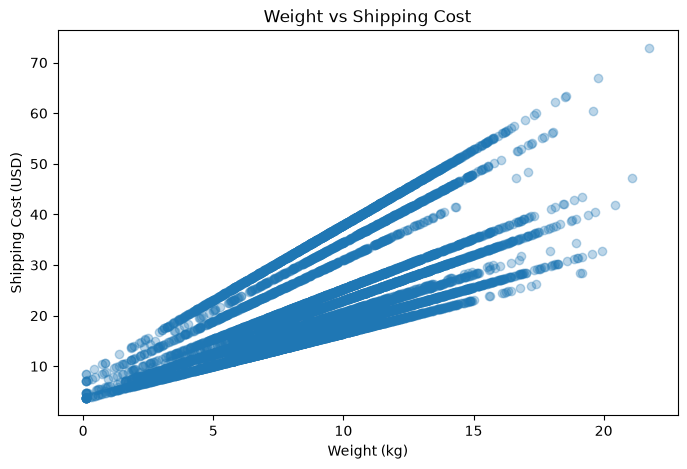

In [114]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["weight_kg"],
    df["shipping_cost_usd"],
    alpha=0.3
)

plt.xlabel("Weight (kg)")
plt.ylabel("Shipping Cost (USD)")
plt.title("Weight vs Shipping Cost")

plt.show()

## 9. Delivery Attempts

The relationship between delivery attempts and delivery performance is
analyzed.

In [117]:
attempt_analysis = df.groupby("delivery_attempts").agg(
    packages=("package_id", "count"),
    avg_delay=("delay_days", "mean"),
    on_time_rate=("on_time", "mean")
).round(3)

attempt_analysis

,packages,avg_delay,on_time_rate
delivery_attempts,,,
1,8371,1.471,0.380728
2,1208,1.376,0.399616
3,306,1.539,0.340824


### Key observation
* **Most packages required only one delivery attempt**, with **8,371 packages (84.7%)**.
* Packages requiring **two attempts** had a slightly higher on-time rate (**39.96%**) than those requiring one attempt (**38.07%**).
* Packages requiring **three attempts** had the lowest on-time rate at **34.08%** and the highest average delay at **1.54 days**.
* The difference between one and two attempts is relatively small, while **three attempts show a clearer deterioration in delivery performance**.

## 10. Monthly Package Volume

Monthly package volume is analyzed to identify significant changes in demand.

In [116]:
df["order_date"] = pd.to_datetime(df["order_date"])

monthly_volume = (
    df.groupby(df["order_date"].dt.to_period("M"))
      .size()
)

monthly_volume

order_date
2026-01    1130
2026-02    1005
2026-03    1129
2026-04    1094
2026-05    1098
2026-06    1101
2026-07    1146
2026-08    1104
2026-09    1078
Freq: M, dtype: int64

### Key observation
* Monthly package volume remained **relatively stable throughout the period**, ranging from **1,005 to 1,146 packages**.
* **July** had the highest package volume with **1,146 packages**.
* **February** had the lowest volume with **1,005 packages**.
* There is **no strong upward or downward trend** in package volume across the nine-month period.

## 11. Key Findings

### 1. Shipping cost vs delivery speed

Express shipping has the highest average cost at $34.12 but also the shortest
average delivery time at 7.25 days. Economy shipping is significantly cheaper
at $16.49 but takes 9.63 days on average.

### 2. Provider performance

Amazon handles the highest package volume and has the shortest average delivery
time at 7.67 days. Temu has the lowest average shipping cost at $16.02 but the
longest average delivery time at 9.55 days.

### 3. Geographical differences

Delivery performance varies across provinces. Guanacaste has the longest
average delivery time at 10.09 days, while Heredia has the shortest at 7.99
days and the highest on-time rate at 40.53%.

### 4. Weight and shipping cost

Package weight has a positive relationship with shipping cost, with a Pearson
correlation of approximately 0.69.

### 5. Delivery attempts

Packages requiring three delivery attempts show the highest average delay and
the lowest on-time delivery rate, suggesting an association between repeated
delivery attempts and poorer delivery performance.

### 6. Package volume

Monthly package volume remains relatively stable throughout the analyzed period,
ranging from 1,005 to 1,146 packages per month, with July having the highest
volume and February the lowest.